In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import ( accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve )
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv('../datasets/alzheimers_disease_data.csv')
print("Shape:", df.shape)
df.head(3)

Shape: (2149, 35)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,...,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,...,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,...,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,...,0,0,7.119548,0,1,0,1,0,0,XXXConfid


In [3]:
df_clean = df.drop(columns=['PatientID', 'DoctorInCharge'])

X = df_clean.drop(columns=['Diagnosis'])
y = df_clean['Diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [4]:
configs = { "Config 1\n(Default XGB)": XGBClassifier( random_state=42, eval_metric='logloss' ),
           "Config 2\n(300 Trees)": XGBClassifier( n_estimators=300, random_state=42, eval_metric='logloss' ),
            "Config 3\n(Low LR)": XGBClassifier( n_estimators=300, learning_rate=0.05, random_state=42, eval_metric='logloss' ),
            "Config 4\n(Depth=10)": XGBClassifier( max_depth=10, random_state=42, eval_metric='logloss' ),
            "Config 5\n(Regularized)": XGBClassifier( reg_alpha=1, reg_lambda=1, random_state=42, eval_metric='logloss' ) }

In [5]:
results = []
for config_name, model in configs.items():
  print(f"\nTraining {config_name}")
  model.fit( X_train, y_train )
  y_pred = model.predict(X_test)
  y_prob = model.predict_proba( X_test )[:,1]
  accuracy = accuracy_score( y_test, y_pred )
  roc_auc = roc_auc_score( y_test, y_prob )
  report = classification_report( y_test, y_pred, output_dict=True )
  precision = report['1']['precision']
  recall = report['1']['recall']
  f1 = report['1']['f1-score']
  results.append({ 'Config':config_name, 'Accuracy':accuracy, 'Precision':precision, 'Recall':recall, 'F1-Score':f1, 'ROC-AUC':roc_auc, '_model':model, '_y_pred':y_pred, '_y_prob':y_prob })
  results_df = pd.DataFrame(results)
  results_df.drop( columns=[ '_model', '_y_pred', '_y_prob' ] )


Training Config 1
(Default XGB)

Training Config 2
(300 Trees)

Training Config 3
(Low LR)

Training Config 4
(Depth=10)

Training Config 5
(Regularized)


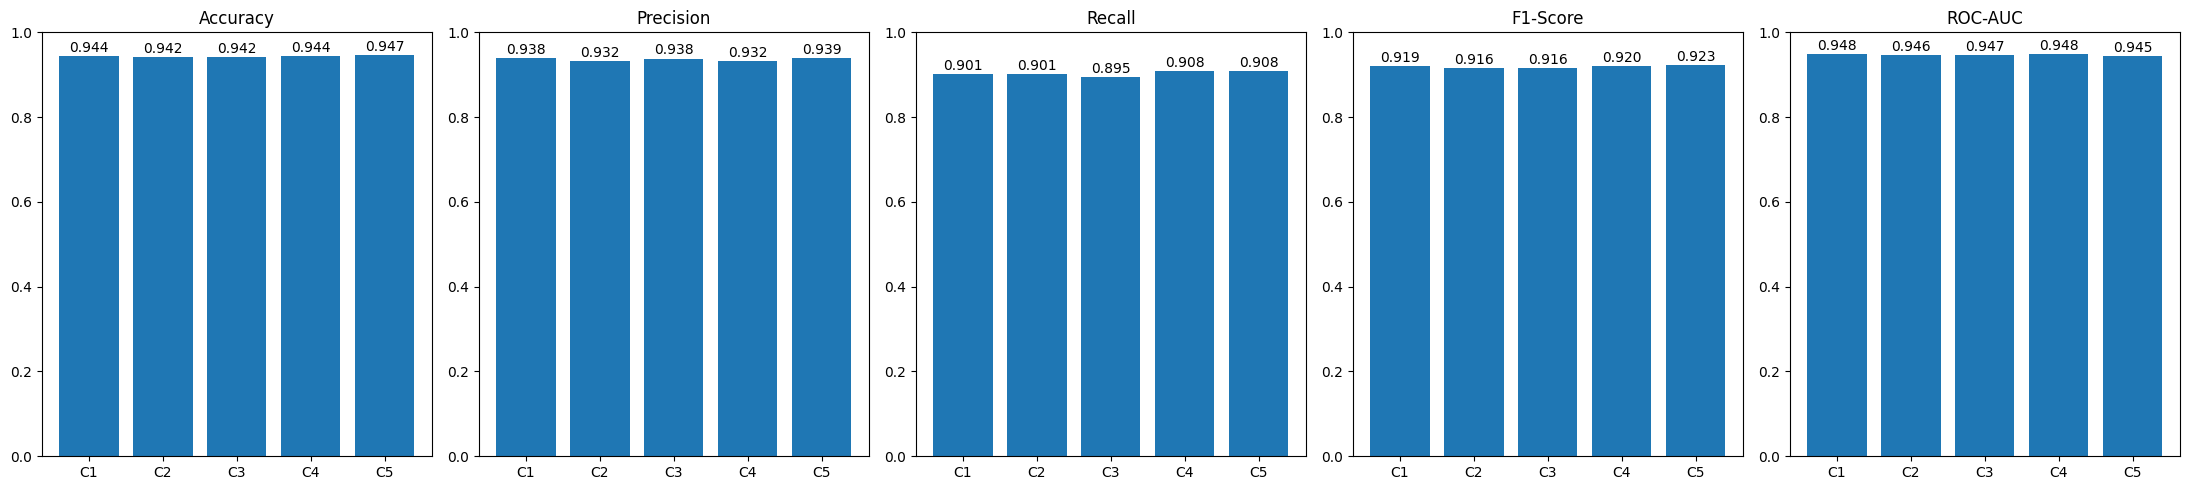

In [6]:
metrics = [ 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC' ]
fig, axes = plt.subplots( 1, 5, figsize=(22,5) )
for i, metric in enumerate(metrics):
  vals = [r[metric] for r in results]
  bars = axes[i].bar( range(len(vals)), vals )
  axes[i].set_title(metric)
  axes[i].set_ylim(0,1)
  axes[i].set_xticks( range(len(vals)) )
  axes[i].set_xticklabels( ['C1','C2','C3','C4','C5'] )
  for bar,val in zip(bars,vals):
    axes[i].text( bar.get_x()+bar.get_width()/2, val+0.01, f"{val:.3f}", ha='center' )
plt.tight_layout()
plt.show()

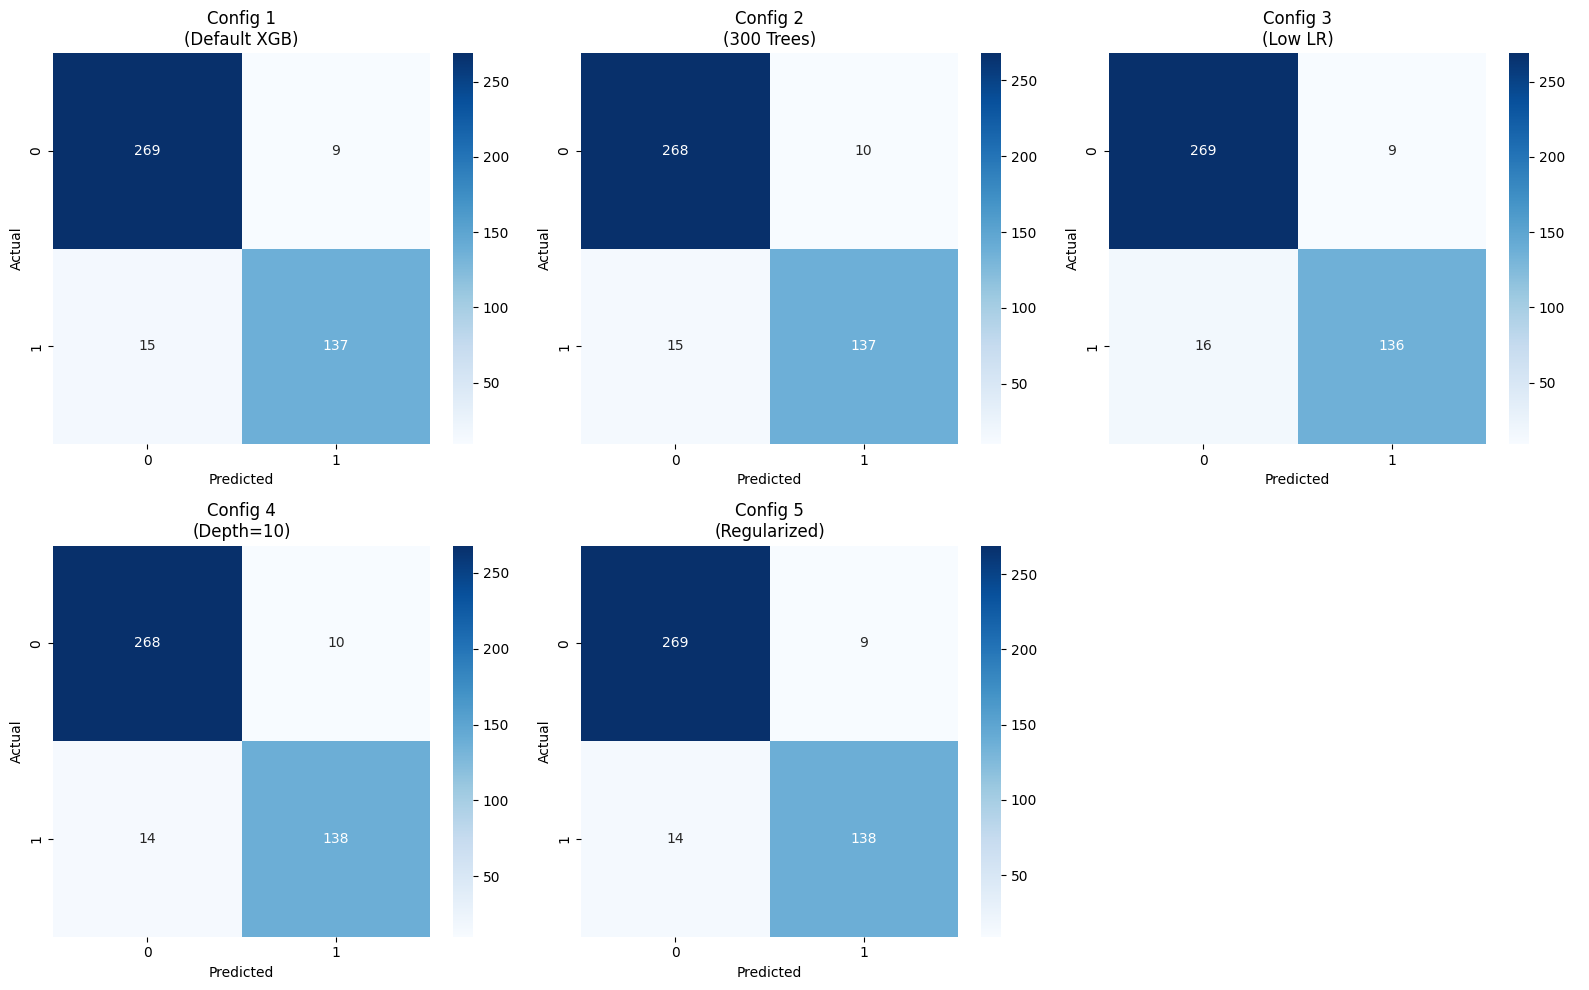

In [7]:
fig, axes = plt.subplots( 2, 3, figsize=(16,10) )
axes = axes.flatten()
for i,r in enumerate(results):
  cm = confusion_matrix( y_test, r['_y_pred'] )
  sns.heatmap( cm, annot=True, fmt='d', cmap='Blues', ax=axes[i] )
  axes[i].set_title( r['Config'] )
  axes[i].set_xlabel( 'Predicted' )
  axes[i].set_ylabel( 'Actual' )
  axes[-1].axis('off')
plt.tight_layout()
plt.show()

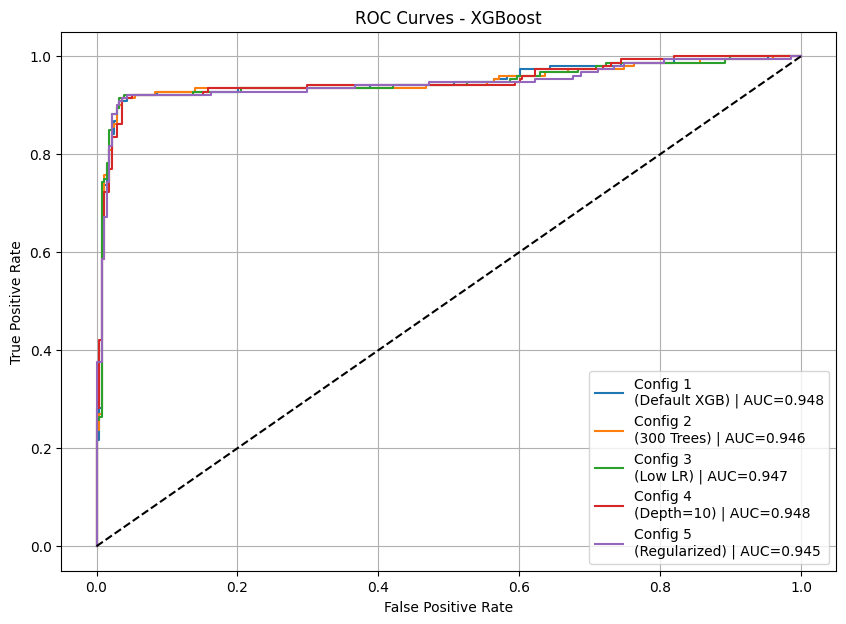

In [8]:
plt.figure(figsize=(10,7))
for r in results:
  fpr,tpr,_ = roc_curve( y_test, r['_y_prob'] )
  plt.plot( fpr, tpr, label=f"{r['Config']} | AUC={r['ROC-AUC']:.3f}" )
plt.plot( [0,1], [0,1], 'k--' )
plt.xlabel( "False Positive Rate" )
plt.ylabel( "True Positive Rate" )
plt.title( "ROC Curves - XGBoost" )
plt.legend()
plt.grid()
plt.show()

In [9]:
best = max( results, key=lambda x:x['ROC-AUC'] )
print( "Best Configuration:", best['Config'] )
print( "ROC-AUC:", round(best['ROC-AUC'],4) )

Best Configuration: Config 1
(Default XGB)
ROC-AUC: 0.948


In [10]:
best_model = best['_model']
importance_df = pd.DataFrame({ 'Feature':X.columns, 'Importance': best_model.feature_importances_ })
importance_df = importance_df.sort_values( by='Importance', ascending=False )
importance_df.head(15)

,Feature,Importance
24,MemoryComplaints,0.176058
25,BehavioralProblems,0.142680
22,MMSE,0.114555
26,ADL,0.110328
23,FunctionalAssessment,0.108000
5,Smoking,0.029822
28,Disorientation,0.029009
0,Age,0.019085
21,CholesterolTriglycerides,0.018741
8,DietQuality,0.016216


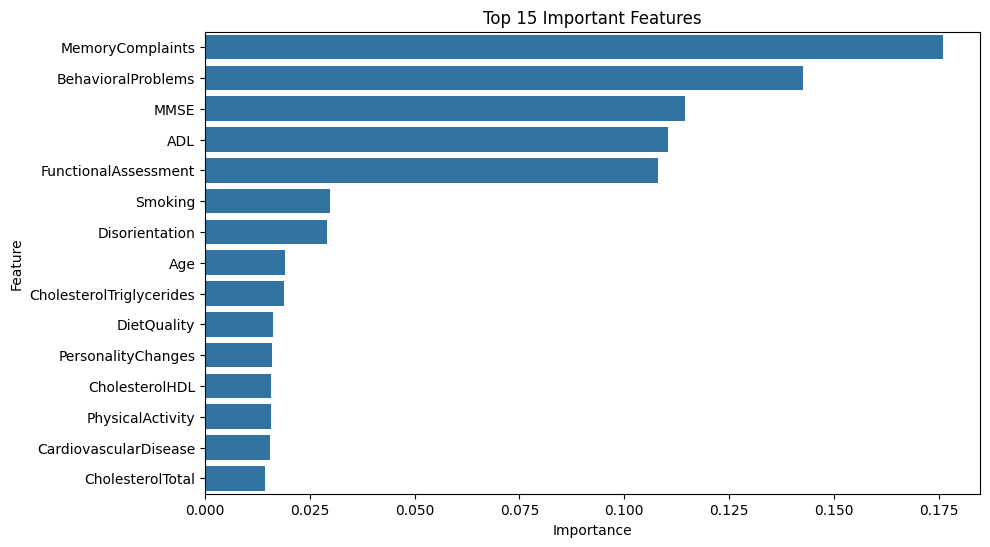

In [11]:
top_features = importance_df.head(15)
plt.figure( figsize=(10,6) )
sns.barplot( data=top_features, x='Importance', y='Feature' )
plt.title( 'Top 15 Important Features' )
plt.show()

In [12]:
summary = results_df.drop( columns=[ '_model', '_y_pred', '_y_prob' ] )
summary = summary.sort_values( by='ROC-AUC', ascending=False )
print("="*80)
print("FINAL XGBOOST RESULTS")
print("="*80)
print( summary.to_string( index=False ) )

FINAL XGBOOST RESULTS
                 Config  Accuracy  Precision   Recall  F1-Score  ROC-AUC
Config 1\n(Default XGB)  0.944186   0.938356 0.901316  0.919463 0.948007
   Config 4\n(Depth=10)  0.944186   0.932432 0.907895  0.920000 0.947747
     Config 3\n(Low LR)  0.941860   0.937931 0.894737  0.915825 0.946706
  Config 2\n(300 Trees)  0.941860   0.931973 0.901316  0.916388 0.945665
Config 5\n(Regularized)  0.946512   0.938776 0.907895  0.923077 0.944671


In [13]:
from joblib import dump

dump(model, '../trained_models/xgboost.pkl')

['../trained_models/xgboost.pkl']